# CIFAR-10 / ResNet18 — headline + parameter-fraction

Sven vs baselines on ResNet18 (Gram makes this tractable). Headline convergence, and the Fig-5 parameter-fraction sweep (accuracy vs fraction of parameters updated).

> Loads the fresh Gram-backend results (schema 2). Robust to partial data (plots whatever has finished).
>
> **The CIFAR-10 CROSS-ENTROPY numbers below are PROVISIONAL.** The decision-5 `rtol`
> extension of `cifar10_resnet_ce_scan` (`rtol` 0.03/0.1/0.3 at `k=128`) was still in
> flight when this notebook was last executed, and the new points are ahead of the
> selected config on the seeds that have landed. Re-run this notebook after
> `tools/select_best.py` when the extension jobs finish (ANALYSIS_PLAN section 7,
> decision 5); the label-regression scan and Fig 5 are complete and unaffected.
>
> **Fig 5 = `rebuttal_fig5_cifar_paramfrac_scan` (3 seeds).** The old 1-seed
> `cifar10_resnet_paramFrac_scan_labelReg` was CUT from the campaign and does not exist
> in the fresh results root (ANALYSIS_PLAN section 1.2); a single seed carries no seed
> band, so nothing is lost by dropping it.

In [1]:
import sys, json
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
sys.path.insert(0, '.')
from style import load_results, average_over_seeds, set_style
from analysis_helpers import (add_derived, best_per_method, seed_mean_best, config_runs, seed_band,
                              errorbar_seeds, fmt_pm, epochs_to_target_table, valid, loss_curve, method_order,
                              n_params_of)
from style import DATASET_TITLES, metric_label, method_label, seed_spread_label
from style import clipped_yerr
from pathlib import Path
set_style()
PLOT_DIR = Path('plots_v2/cifar'); PLOT_DIR.mkdir(parents=True, exist_ok=True)
from style import method_color
def sven_color(m): return method_color(m)   # global optimizer colours (style.METHOD_COLORS)
def sven_lw(m):    return 2.6 if m=='Sven' else 1.6

In [2]:
head={DATASET_TITLES['cifar_labelreg']:'cifar10_resnet_scan_labelRegression', DATASET_TITLES['cifar_ce']:'cifar10_resnet_ce_scan'}
# Fig 5: the 3-seed rebuttal scan.  The 1-seed `cifar10_resnet_paramFrac_scan_labelReg`
# was cut from the campaign (ANALYSIS_PLAN 1.2) and is not in the fresh root.
pf={'label-reg (3 seeds)':'rebuttal_fig5_cifar_paramfrac_scan'}
H={}; PF={}
for t,n in head.items():
    try: H[t]=add_derived(load_results(n))
    except FileNotFoundError: print('missing',n)
for t,n in pf.items():
    try: PF[t]=add_derived(load_results(n))
    except FileNotFoundError: print('missing',n)

Loaded 600 runs from ../experiment_results/_cache/cifar10_resnet_scan_labelRegression.slim.pkl (slim cache)


Loaded 753 runs from ../experiment_results/cifar10_resnet_ce_scan/ (directory format, slim)
Loaded 15 runs from ../experiment_results/_cache/rebuttal_fig5_cifar_paramfrac_scan.slim.pkl (slim cache)


### Headline: best per method

In [3]:
for t,df in H.items():
    b=best_per_method(df, by='final_val_loss').sort_values('final_val_loss')
    print(f'== {t} ==  (best config per optimizer by seed-mean val loss; mean {seed_spread_label(plain=True)})')
    for _,r in b.iterrows():
        acc=f"  acc={fmt_pm(r,'final_val_acc','.3f')}" if r.final_val_acc==r.final_val_acc else ''
        print(f"  {method_label(r.method):18s} val={fmt_pm(r,'final_val_loss','.4f')}{acc}  seeds={r.n_seeds} diverged={r.n_diverged}")

== CIFAR-10 (label reg.) ==  (best config per optimizer by seed-mean val loss; mean ± 1 std over seeds)
  MuonW              val=0.3456 ± 0.0101  acc=0.760 ± 0.006  seeds=5 diverged=0
  SOAP               val=0.3524 ± 0.0108  acc=0.781 ± 0.005  seeds=5 diverged=0
  Muon               val=0.3649 ± 0.0064  acc=0.778 ± 0.005  seeds=5 diverged=0
  AdamW              val=0.3952 ± 0.0082  acc=0.732 ± 0.008  seeds=5 diverged=0
  Adam               val=0.3985 ± 0.0193  acc=0.732 ± 0.010  seeds=5 diverged=0
  RMSprop            val=0.4088 ± 0.0174  acc=0.743 ± 0.010  seeds=5 diverged=0
  Stochastic L-BFGS  val=0.4380 ± 0.0225  acc=0.714 ± 0.009  seeds=5 diverged=0
  Polyak SGD         val=0.4541 ± 0.0098  acc=0.703 ± 0.010  seeds=5 diverged=0
  Sven               val=0.4803 ± 0.0133  acc=0.700 ± 0.008  seeds=5 diverged=0
  SGD + momentum     val=0.6922 ± 0.0205  acc=0.537 ± 0.011  seeds=5 diverged=0
  SGD                val=0.7390 ± 0.0114  acc=0.448 ± 0.011  seeds=5 diverged=0
== CIFAR-10 (CE)

### Fig-5: accuracy vs parameter fraction (Sven)

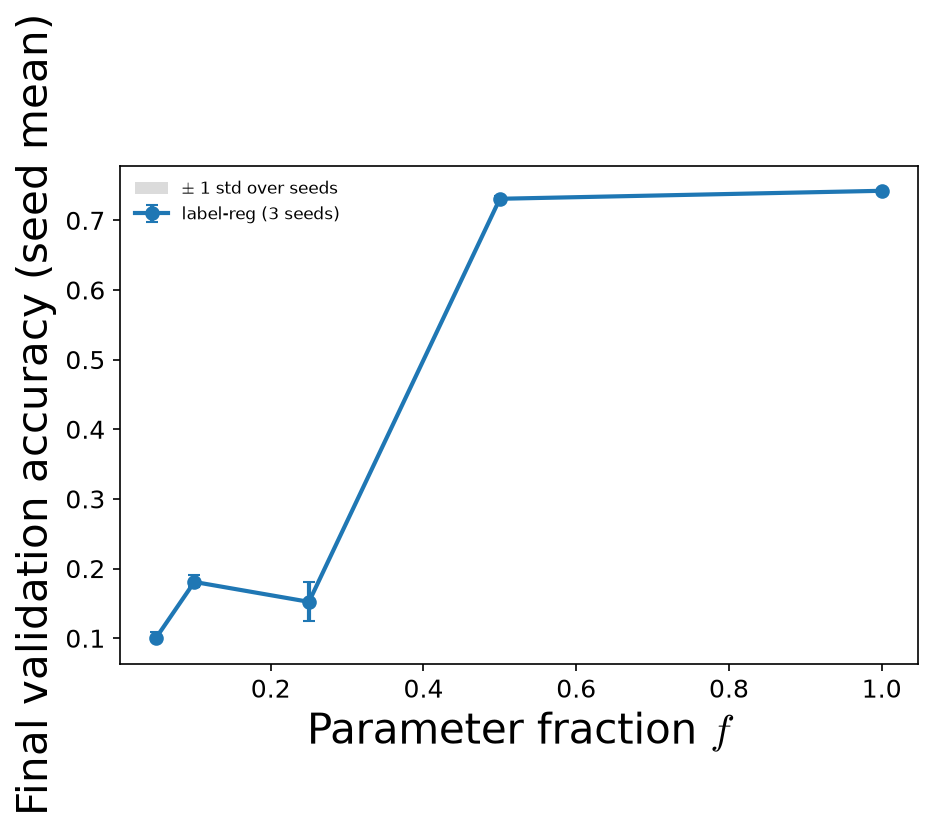

In [4]:
fig,ax=plt.subplots(figsize=(6.5,4.4))
q = 'final_val_acc'   # what the y axis shows (falls back to loss below if no accuracy)
for t,df in PF.items():
    if 'param_fraction' not in df or df.empty: continue
    # best config per param_fraction by SEED-MEAN val loss; error bars = seed spread
    g=seed_mean_best(df, 'param_fraction')
    q = 'final_val_acc' if g['final_val_acc'].notna().any() else 'final_val_loss'
    errorbar_seeds(ax, g, 'param_fraction', q, label=t)
ax.set_xlabel('Parameter fraction $f$'); ax.set_ylabel(metric_label(q)); ax.legend(fontsize=8)
plt.tight_layout(); plt.savefig(PLOT_DIR/'paramfrac.pdf',bbox_inches='tight'); plt.show()